
# Autoencoder para compresión de imágenes de dígitos con PyTorch

Este notebook muestra, paso a paso, cómo implementar un **autoencoder** usando **PyTorch** para comprimir imágenes de dígitos.

La idea principal es sencilla:

- La **entrada** es una imagen de un dígito.
- El **encoder** transforma la imagen a una representación más pequeña.
- El **decoder** intenta reconstruir la imagen original a partir de esa representación comprimida.

De esta forma, el modelo aprende una versión reducida de la imagen que conserva la información más importante.



## 1. Objetivos de aprendizaje

Al finalizar este notebook deberías poder:

1. Entender qué es un autoencoder y por qué sirve para compresión.
2. Cargar un dataset pequeño de imágenes de dígitos.
3. Preparar los datos para PyTorch.
4. Definir la arquitectura del autoencoder.
5. Entrenar el modelo.
6. Visualizar reconstrucciones.
7. Interpretar la compresión mediante el espacio latente.



## 2. Requisitos para ejecutar el notebook

### Requisitos de software

Se recomienda usar:

- Python 3.10 o superior
- Jupyter Notebook o JupyterLab

### Librerías necesarias

Este notebook usa las siguientes librerías:

- `torch`
- `torchvision` (no es estrictamente obligatoria aquí, pero suele venir con PyTorch)
- `numpy`
- `matplotlib`
- `scikit-learn`

### Instalación sugerida

En una terminal, puedes instalar lo necesario con:

```bash
pip install torch torchvision numpy matplotlib scikit-learn notebook
```

### Ejecución

1. Guarda este archivo `.ipynb`.
2. Abre una terminal en la carpeta donde está el notebook.
3. Ejecuta:

```bash
jupyter notebook
```

o, si usas JupyterLab:

```bash
jupyter lab
```

4. Abre el notebook y ejecuta las celdas en orden.

### Requisitos de hardware

- Este ejemplo puede ejecutarse en **CPU** sin problema.
- Si tienes **GPU** y PyTorch la detecta, el entrenamiento será más rápido.



## 3. ¿Qué es un autoencoder?

Un **autoencoder** es una red neuronal que intenta aprender la función identidad:

\[
f(x) \approx x
\]

pero con una restricción importante: primero obliga a pasar la información por una representación más compacta.

Se compone de dos partes:

### Encoder
Convierte la entrada original en un vector más pequeño:

\[
x \rightarrow z
\]

donde `z` es la representación comprimida o **espacio latente**.

### Decoder
Reconstruye la entrada a partir de `z`:

\[
z \rightarrow \hat{x}
\]

El entrenamiento busca que la reconstrucción `\hat{x}` sea lo más parecida posible a la imagen original `x`.

### ¿Por qué esto sirve para compresión?

Porque si el vector latente tiene menos dimensiones que la entrada original, el modelo se ve obligado a conservar solo la información más relevante.


In [16]:

# 4. Importación de librerías

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


In [17]:

# 5. Configuración inicial

# Fijamos semillas para hacer el experimento más reproducible
np.random.seed(42)
torch.manual_seed(42)

# Detectamos si hay GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo en uso:", device)


Dispositivo en uso: cpu



## 4. Carga del dataset

Usaremos el dataset `digits` de `scikit-learn`.

Características del dataset:

- Contiene imágenes de dígitos del `0` al `9`.
- Cada imagen tiene tamaño **8 x 8**.
- Los valores de intensidad van aproximadamente de `0` a `16`.

Como trabajaremos con una red neuronal, normalizaremos los valores a un rango entre `0` y `1`.


In [18]:

# 6. Cargar dataset de dígitos

digits = load_digits()

X = digits.images   # forma: (n_muestras, 8, 8)
y = digits.target

print("Forma original de X:", X.shape)
print("Forma de y:", y.shape)


Forma original de X: (1797, 8, 8)
Forma de y: (1797,)


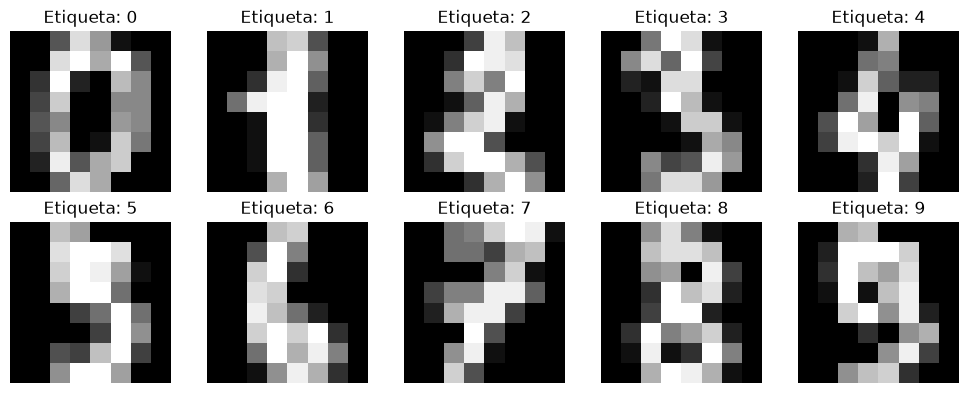

In [19]:

# Visualizamos algunos ejemplos

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i], cmap="gray")
    ax.set_title(f"Etiqueta: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()



## 5. Preprocesamiento

### Paso 1: normalización

Como los píxeles están en el rango `0` a `16`, dividimos entre `16.0` para llevarlos al rango `0` a `1`.

### Paso 2: vectorización

Cada imagen es de `8 x 8`, es decir, tiene `64` píxeles.  
Para este primer autoencoder usaremos una arquitectura totalmente conectada, así que aplanaremos cada imagen a un vector de longitud `64`.

### Paso 3: división en entrenamiento y prueba

Separaremos los datos para poder evaluar si el modelo reconstruye bien imágenes que no vio durante el entrenamiento.


In [20]:

# 7. Normalización y aplanado

X = X / 16.0
X = X.reshape(-1, 64)

print("Nueva forma de X:", X.shape)
print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())


Nueva forma de X: (1797, 64)
Valor mínimo: 0.0
Valor máximo: 1.0


In [21]:

# 8. División en train y test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (1437, 64)
Test : (360, 64)



## 6. Conversión a tensores y DataLoaders

En PyTorch normalmente trabajamos con:

- **Tensores**, que son la estructura básica de datos.
- **DataLoader**, que permite iterar en mini-batches durante el entrenamiento.

Como el objetivo del autoencoder es reconstruir la misma entrada, tanto la entrada como la salida esperada serán `X`.


In [22]:

# 9. Convertir a tensores de PyTorch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
test_dataset = TensorDataset(X_test_tensor, X_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

len(train_loader), len(test_loader)


(45, 12)


## 7. Definición del autoencoder

Construiremos un autoencoder pequeño y fácil de entender.

### Arquitectura propuesta

#### Encoder
- 64 → 32
- 32 → 16

#### Decoder
- 16 → 32
- 32 → 64

La capa de tamaño `16` será nuestro **cuello de botella** (*bottleneck*), es decir, la representación comprimida.

### Funciones de activación

Usaremos:

- `ReLU` en las capas internas
- `Sigmoid` en la salida

Usamos `Sigmoid` al final porque los píxeles fueron normalizados al rango `[0, 1]`.


In [31]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        # El encoder reduce de 64 -> 32 -> el tamaño que elijamos
        self.encoder = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
            nn.ReLU()
        )

        # El decoder reconstruye desde el tamaño elegido -> 32 -> 64
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_reconstruida = self.decoder(z)
        return x_reconstruida

In [24]:

# 11. Crear modelo y moverlo al dispositivo

model = Autoencoder().to(device)
print(model)


Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): Sigmoid()
  )
)



## 8. Función de pérdida y optimizador

### Función de pérdida

Como queremos que la imagen reconstruida sea parecida a la original, usaremos el **error cuadrático medio**:

\[
MSE = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{x}_i)^2
\]

Esta pérdida mide qué tan diferentes son los píxeles reconstruidos respecto a los originales.

### Optimizador

Usaremos **Adam**, porque suele funcionar bien en muchos problemas sin demasiada calibración inicial.


In [25]:

# 12. Configuración del entrenamiento

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50



## 9. Entrenamiento

En cada época:

1. Recorremos los mini-batches del conjunto de entrenamiento.
2. Generamos reconstrucciones.
3. Calculamos la pérdida.
4. Hacemos backpropagation.
5. Actualizamos los pesos.

Además, guardaremos la pérdida promedio por época para luego visualizarla.


In [26]:

# 13. Bucle de entrenamiento

train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_x.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Época [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.6f}")


Época [1/50] - Loss: 0.163210
Época [10/50] - Loss: 0.048153
Época [20/50] - Loss: 0.028774
Época [30/50] - Loss: 0.025827
Época [40/50] - Loss: 0.021804
Época [50/50] - Loss: 0.019427


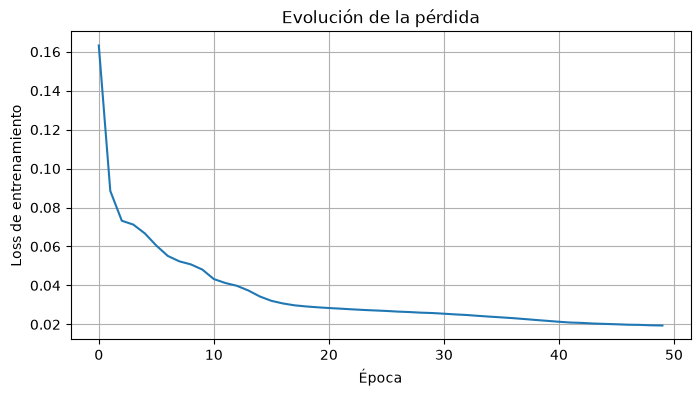

In [27]:

# 14. Visualizar la evolución de la pérdida

plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.xlabel("Época")
plt.ylabel("Loss de entrenamiento")
plt.title("Evolución de la pérdida")
plt.grid(True)
plt.show()



## 10. Evaluación cualitativa: imágenes reconstruidas

Ahora compararemos:

- la imagen original
- la imagen reconstruida por el autoencoder

Esto permite ver si la compresión mantiene la estructura principal del dígito.


In [28]:

# 15. Obtener reconstrucciones del conjunto de prueba

model.eval()

with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    reconstructed = model(X_test_device).cpu().numpy()


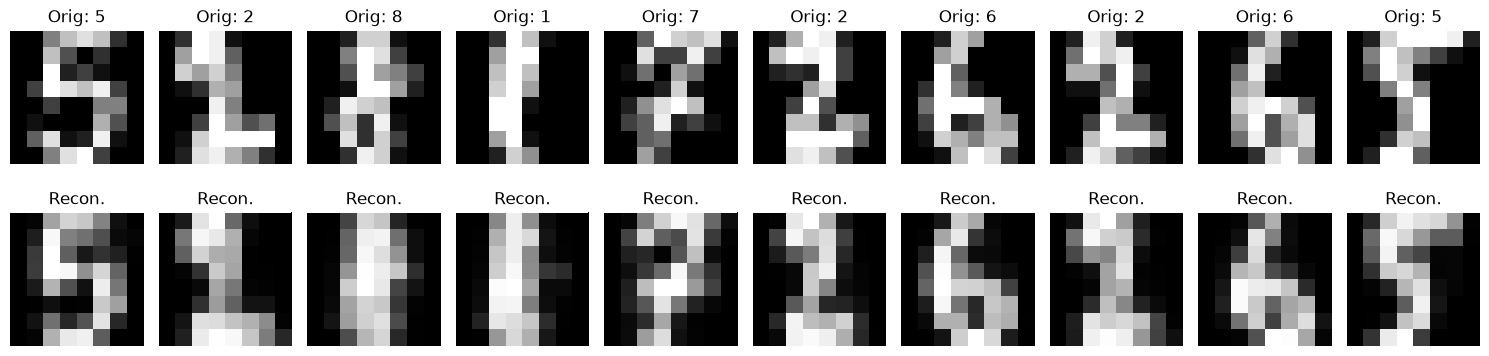

In [29]:

# 16. Visualizar imágenes originales vs reconstruidas

n = 10
fig, axes = plt.subplots(2, n, figsize=(15, 4))

for i in range(n):
    # Original
    axes[0, i].imshow(X_test[i].reshape(8, 8), cmap="gray")
    axes[0, i].set_title(f"Orig: {y_test[i]}")
    axes[0, i].axis("off")

    # Reconstruida
    axes[1, i].imshow(reconstructed[i].reshape(8, 8), cmap="gray")
    axes[1, i].set_title("Recon.")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()



## 11. Analizando la compresión

Recordemos:

- La imagen original tiene **64 valores**
- La representación latente tiene **16 valores**

Eso significa que el modelo aprendió a representar cada imagen usando un vector más pequeño.

No es una compresión perfecta en el sentido clásico de formatos como ZIP o PNG, pero sí es una **compresión aprendida**, porque la red descubre automáticamente qué información preservar.


In [30]:

# 17. Obtener representaciones latentes

with torch.no_grad():
    latent_vectors = model.encoder(X_test_tensor.to(device)).cpu().numpy()

print("Forma del espacio latente:", latent_vectors.shape)
print("Primer vector latente:")
print(latent_vectors[0])


Forma del espacio latente: (360, 16)
Primer vector latente:
[8.3306465 6.233798  7.645746  0.        1.7558832 4.4784255 6.163216
 0.        1.5256889 0.        0.        3.859846  6.0154524 0.
 0.        1.6788688]



## 12. Interpretación de resultados

Si el entrenamiento fue correcto, deberías observar que:

1. La pérdida disminuye con las épocas.
2. Las reconstrucciones se parecen bastante a las imágenes originales.
3. Algunos detalles finos pueden perderse, porque el modelo está obligado a comprimir.

### ¿Qué aprendió realmente el modelo?

El autoencoder no memoriza simplemente imágenes. Más bien aprende regularidades como:

- trazos comunes de los dígitos,
- formas típicas,
- patrones de brillo.

Por eso puede reconstruir bastante bien imágenes nuevas del conjunto de prueba.



## 13. Ejercicios

Aquí tienes algunas ideas para seguir explorando:

### A. Cambiar el tamaño del cuello de botella
Prueba reemplazar la dimensión latente de `16` por:

- `2` → mayor compresión, pero posiblemente peor reconstrucción
- `32` → menor compresión, pero mejor reconstrucción

1. ¿Qué pasa si el espacio latente tiene tamaño 2, 4, 8, 16 o 32?
2. ¿Cómo cambia visualmente la calidad de reconstrucción?
3. ¿En qué punto la compresión empieza a degradar demasiado la imagen?

### B. Entrenar más épocas
Probar con `100` o `150` épocas y comparar.

### C. Añadir ruido y entrenar un denoising autoencoder
Corrompe las imágenes de entrada y pedir al modelo que reconstruya la imagen limpia.


## 14. Resolución de Ejercicios

### A. Cambiar el tamaño del cuello de botella
Este codigo se encarga de entrenar un modelo independiente para cada tamaño y guardara los resultados en una gráfica comparativa.


Iniciando experimento del Ejercicio A...

-> Entrenando autoencoder con espacio latente de tamaño: 2
-> Entrenando autoencoder con espacio latente de tamaño: 4
-> Entrenando autoencoder con espacio latente de tamaño: 8
-> Entrenando autoencoder con espacio latente de tamaño: 16
-> Entrenando autoencoder con espacio latente de tamaño: 32

¡Entrenamiento completado! Generando gráfica comparativa...


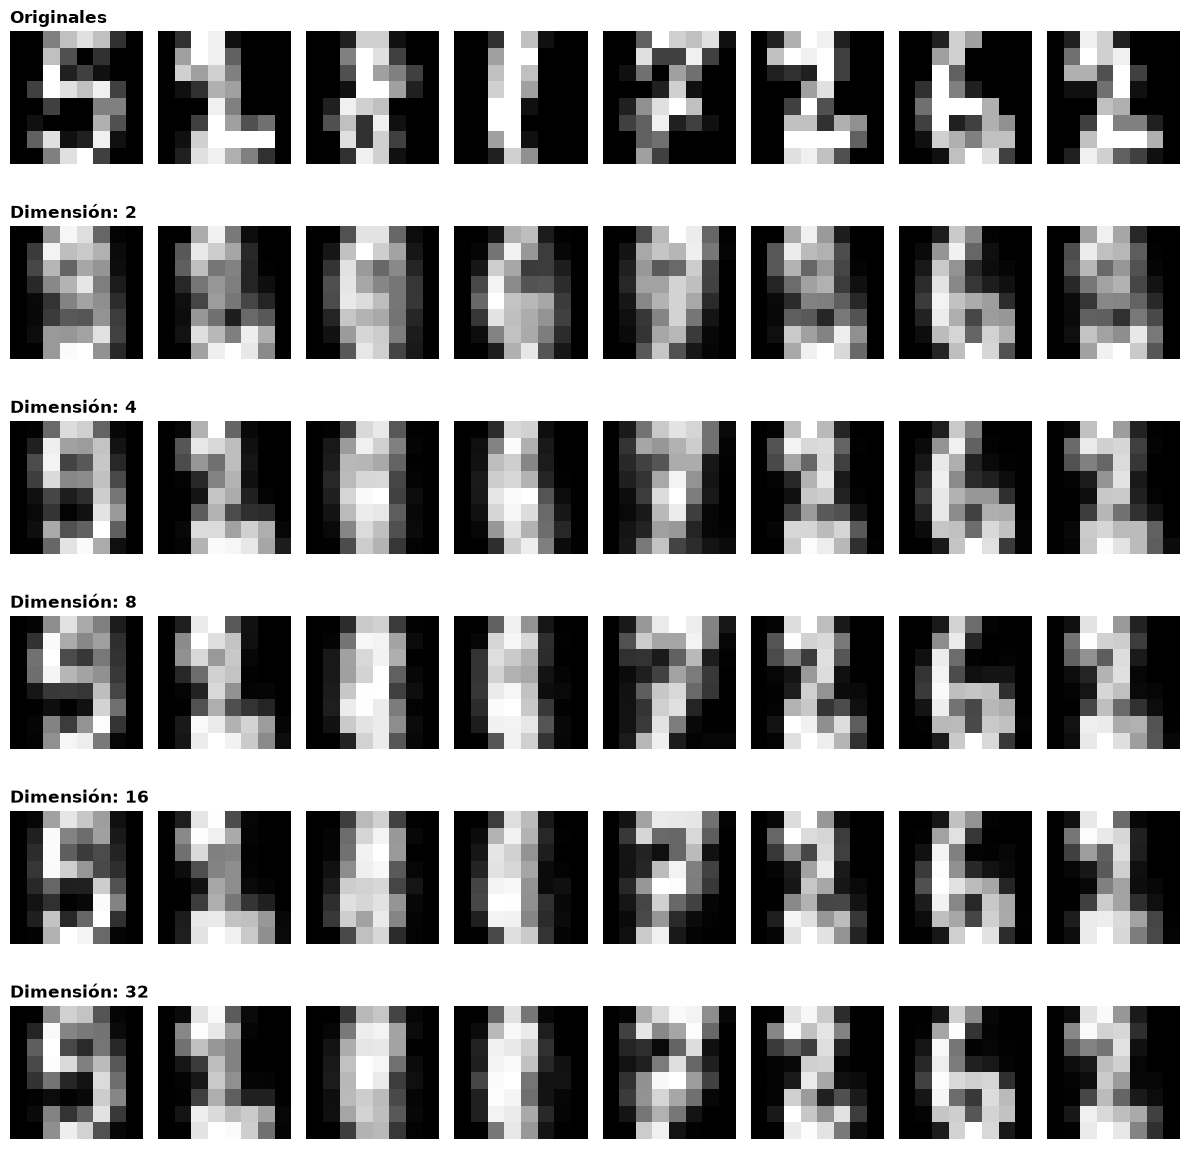

In [33]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


latent_sizes = [2, 4, 8, 16, 32]
reconstructions = {}


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Iniciando experimento del Ejercicio A...\n")

for size in latent_sizes:
    print(text := f"-> Entrenando autoencoder con espacio latente de tamaño: {size}")
    
    
    model = Autoencoder(latent_dim=size).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    
    num_epochs = 40
    model.train()
    for epoch in range(num_epochs):
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
    
    model.eval()
    with torch.no_grad():
        X_test_device = X_test_tensor.to(device)
        reconstructions[size] = model(X_test_device).cpu().numpy()

print("\n¡Entrenamiento completado! Generando gráfica comparativa...")


n_images = 8  
fig, axes = plt.subplots(len(latent_sizes) + 1, n_images, figsize=(12, 2 * (len(latent_sizes) + 1)))


for i in range(n_images):
    axes[0, i].imshow(X_test[i].reshape(8, 8), cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Originales", loc="left", fontweight="bold")


for r_idx, size in enumerate(latent_sizes):
    for i in range(n_images):
        axes[r_idx + 1, i].imshow(reconstructions[size][i].reshape(8, 8), cmap="gray")
        axes[r_idx + 1, i].axis("off")
        if i == 0:
            axes[r_idx + 1, i].set_title(f"Dimensión: {size}", loc="left", fontweight="bold")

plt.tight_layout()
plt.show()

### Conclusiones del Experimento: Tamaño del Espacio Latente (Ejercicio A)

#### 1. ¿Qué pasa si el espacio latente tiene tamaño 2, 4, 8, 16 o 32?
* **Dimensiones bajas (2 y 4):** Se genera un "cuello de botella" extremadamente angosto. La red neuronal se ve obligada a comprimir drásticamente las 64 dimensiones originales, lo que provoca una pérdida masiva de información. El modelo no logra retener las características geométricas únicas de cada número.
* **Dimensiones intermedias (8 y 16):** Representan el punto de equilibrio óptimo. 16 dimensiones son suficientes para codificar las características más importantes (trazos, curvas, inclinaciones) sin saturar la red, permitiendo una reconstrucción muy fiel.
* **Dimensiones altas (32):** El cuello de botella es demasiado ancho. Al tener la mitad de las dimensiones originales, la red no se ve presionada a realizar una compresión real; simplemente transmite los datos casi de forma directa, lo que reduce la utilidad del autoencoder como reductor de dimensionalidad.

#### 2. ¿Cómo cambia visualmente la calidad de reconstrucción?
* **Con tamaño 2 y 4:** Las imágenes reconstruidas se vuelven sumamente de baja resolución, borrosas y abstractas. Los trazos se difuminan tanto que dígitos morfológicamente complejos o similares (como el 3, el 8 o el 9) se vuelven indistinguibles entre sí.
* **Con tamaño 8:** Los dígitos ya son perfectamente legibles, aunque pueden presentar bordes ligeramente suavizados o pérdida de pequeños detalles finos de brillo y contraste.
* **Con tamaño 16 y 32:** La reconstrucción visual es excelente. Los números recuperan su nitidez original, sus bordes definidos y la intensidad correcta de los píxeles, siendo prácticamente idénticos a las muestras reales de prueba.

#### 3. ¿En qué punto la compresión empieza a degradar demasiado la imagen?
* El **punto crítico de degradación destructiva se encuentra por debajo de 8 dimensiones**. A partir de 4 dimensiones hacia abajo, la pérdida de fidelidad geométrica es inaceptable para tareas posteriores de clasificación o reconocimiento. Esto se debe a que un espacio bidimensional (2) o tetradimensional (4) no posee la capacidad matemática suficiente para separar y mapear limpiamente la topología de 10 clases de dígitos distintos (0 al 9).

### B. Entrenar más epocas
El objetivo es evaluar como afecta el tiempo de entrenamiento a la convergencia del modelo y la nitidez de la reconstrucción. Tomamos un tamaño fijo de espacio lantente (16) y comparamos el entrenamiento clasico de 50 épocas frente a un entrenamiento extendido de 150 épocas.

-> Entrenando modelo por 50 épocas...
-> Entrenando modelo por 150 épocas...

Experimento finalizado. Generando gráficas de comparación...


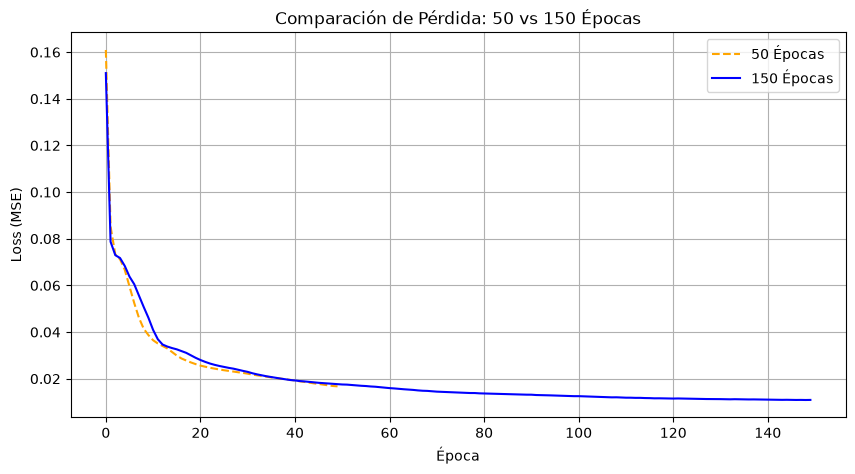

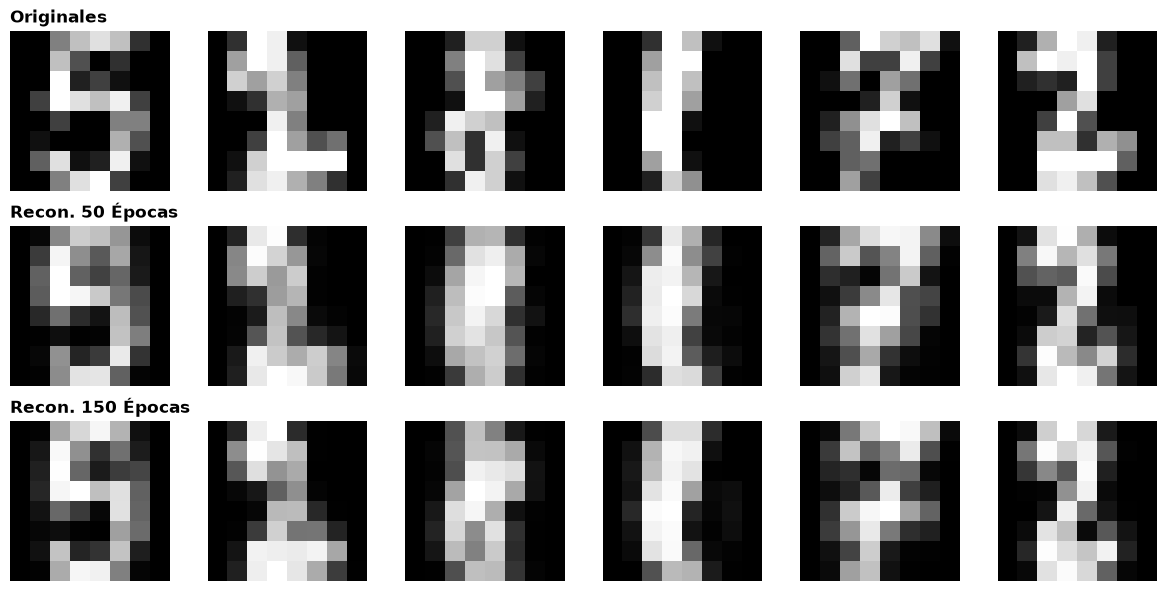

Loss final con 50 épocas: 0.016733
Loss final con 150 épocas: 0.010914


In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

DIM_LATENTE = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def entrenar_modelo(epochs):
    print(f"-> Entrenando modelo por {epochs} épocas...")
    modelo_local = Autoencoder(latent_dim=DIM_LATENTE).to(device)
    criterio_local = nn.MSELoss()
    optimizador_local = optim.Adam(modelo_local.parameters(), lr=0.001)
    
    historial_perdida = []
    
    for epoch in range(epochs):
        modelo_local.train()
        running_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            optimizador_local.zero_grad()
            outputs = modelo_local(batch_x)
            loss = criterio_local(outputs, batch_y)
            loss.backward()
            optimizador_local.step()
            
            running_loss += loss.item() * batch_x.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        historial_perdida.append(epoch_loss)
        
    
    modelo_local.eval()
    with torch.no_grad():
        X_test_device = X_test_tensor.to(device)
        recon = modelo_local(X_test_device).cpu().numpy()
        
    return historial_perdida, recon, modelo_local


loss_50, recon_50, mod_50 = entrenar_modelo(epochs=50)
loss_150, recon_150, mod_150 = entrenar_modelo(epochs=150)

print("\nExperimento finalizado. Generando gráficas de comparación...")


plt.figure(figsize=(10, 5))
plt.plot(loss_50, label="50 Épocas", color="orange", linestyle="--")
plt.plot(loss_150, label="150 Épocas", color="blue")
plt.xlabel("Época")
plt.ylabel("Loss (MSE)")
plt.title("Comparación de Pérdida: 50 vs 150 Épocas")
plt.legend()
plt.grid(True)
plt.show()


n_images = 6
fig, axes = plt.subplots(3, n_images, figsize=(12, 6))

for i in range(n_images):
    
    axes[0, i].imshow(X_test[i].reshape(8, 8), cmap="gray")
    axes[0, i].axis("off")
    if i == 0: axes[0, i].set_title("Originales", loc="left", fontweight="bold")
    
    
    axes[1, i].imshow(recon_50[i].reshape(8, 8), cmap="gray")
    axes[1, i].axis("off")
    if i == 0: axes[1, i].set_title("Recon. 50 Épocas", loc="left", fontweight="bold")
    
    
    axes[2, i].imshow(recon_150[i].reshape(8, 8), cmap="gray")
    axes[2, i].axis("off")
    if i == 0: axes[2, i].set_title("Recon. 150 Épocas", loc="left", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Loss final con 50 épocas: {loss_50[-1]:.6f}")
print(f"Loss final con 150 épocas: {loss_150[-1]:.6f}")

### C. Añadir ruido y entrenar un denoising autoencoder
Se le dara imagenes llenas de estatica a la red neuronal, pero la obligaremos a que el resultado final sea igual que la imagen original limpia. Al hacer esto la red tiene que aprender cuales son los patrones reales que forman un digito y cuales son pixeles basura.

Iniciando entrenamiento del Denoising Autoencoder...

¡Entrenamiento finalizado! Evaluando cómo limpia los datos de prueba...


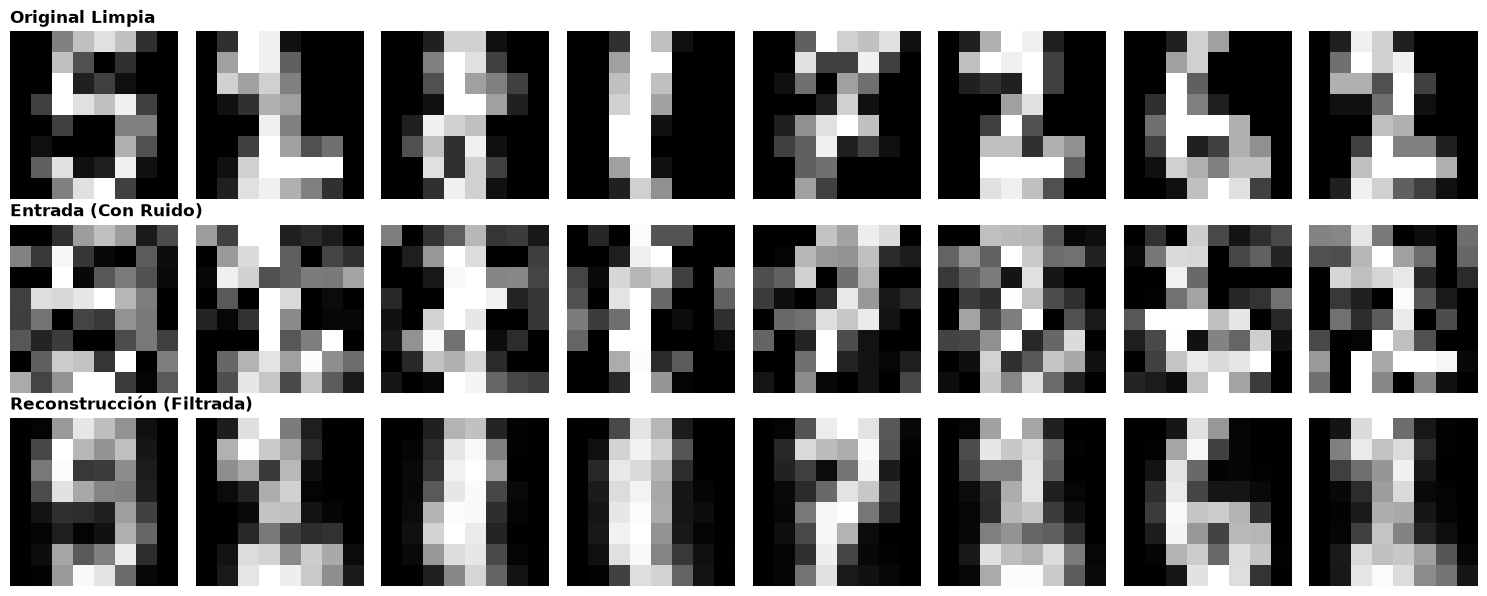

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


DIM_LATENTE = 16
FACTOR_RUIDO = 0.3 
num_epochs_denoising = 50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


modelo_denoising = Autoencoder(latent_dim=DIM_LATENTE).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(modelo_denoising.parameters(), lr=0.001)

print("Iniciando entrenamiento del Denoising Autoencoder...\n")

historial_loss_denoising = []

for epoch in range(num_epochs_denoising):
    modelo_denoising.train()
    running_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device) 
        
        
        ruido = torch.randn_like(batch_x) * FACTOR_RUIDO
        batch_x_ruidoso = torch.clamp(batch_x + ruido, 0., 1.) 
        
        optimizer.zero_grad()
        
        
        outputs = modelo_denoising(batch_x_ruidoso)
        
        
        loss = criterion(outputs, batch_y)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * batch_x.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    historial_loss_denoising.append(epoch_loss)

print("¡Entrenamiento finalizado! Evaluando cómo limpia los datos de prueba...")


modelo_denoising.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    
    
    ruido_test = torch.randn_like(X_test_device) * FACTOR_RUIDO
    X_test_ruidoso = torch.clamp(X_test_device + ruido_test, 0., 1.)
    
    
    recon_denoising = modelo_denoising(X_test_ruidoso).cpu().numpy()
    X_test_ruidoso_np = X_test_ruidoso.cpu().numpy()


n_images = 8
fig, axes = plt.subplots(3, n_images, figsize=(15, 6))

for i in range(n_images):
    
    axes[0, i].imshow(X_test[i].reshape(8, 8), cmap="gray")
    axes[0, i].axis("off")
    if i == 0: axes[0, i].set_title("Original Limpia", loc="left", fontweight="bold")
    
    
    axes[1, i].imshow(X_test_ruidoso_np[i].reshape(8, 8), cmap="gray")
    axes[1, i].axis("off")
    if i == 0: axes[1, i].set_title("Entrada (Con Ruido)", loc="left", fontweight="bold")
    
    
    axes[2, i].imshow(recon_denoising[i].reshape(8, 8), cmap="gray")
    axes[2, i].axis("off")
    if i == 0: axes[2, i].set_title("Reconstrucción (Filtrada)", loc="left", fontweight="bold")

plt.tight_layout()
plt.show()

### Conclusiones del Experimento: Denoising Autoencoder (Ejercicio C)

#### 1. ¿Cómo funciona la arquitectura en este contexto?
Al inyectar ruido gaussiano (estática) en los datos de entrada (`batch_x_ruidoso`) pero mantener las imágenes originales limpias como objetivo de la función de pérdida (`batch_y`), alteramos el propósito de la red. El autoencoder deja de ser una simple función de identidad (que copia la entrada en la salida) y se convierte en un filtro de extracción de características robustas.

#### 2. Efecto en el Espacio Latente
El cuello de botella ahora se ve forzado a ignorar las fluctuaciones aleatorias de los píxeles (el ruido) porque matemáticamente el ruido no tiene un patrón predecible que ayude a minimizar el Error Cuadrático Medio (MSE). En consecuencia, el espacio latente aprende a codificar únicamente la estructura semántica subyacente de la imagen (las líneas, bucles y diagonales que forman los dígitos reales).

#### 3. Análisis Cualitativo Visual
Como se observa en la gráfica de 3 filas:
* **Entrada Ruidosa:** Presenta artefactos visuales severos que dificultan la legibilidad de los dígitos, simulando imágenes capturadas con sensores defectuosos o en condiciones de baja iluminación.
* **Salida Reconstruida:** El modelo es capaz de "limpiar" la imagen de forma impresionante. Logra eliminar los píxeles anómalos del fondo devolviéndolos a tonos oscuros (cercanos a 0) y realza la intensidad de los trazos principales, reconstruyendo la morfología del dígito con gran fidelidad respecto a la versión original limpia.